# Customer Churn Prediction


## 1. Imports

In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import os
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)

In [28]:
import kagglehub


path = kagglehub.dataset_download("muhammadshahidazeem/customer-churn-dataset")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/muhammadshahidazeem/customer-churn-dataset/versions/1


## 2. Load Dataset & Identify Instances


In [29]:
df = pd.read_csv(os.path.join(path, 'customer_churn_dataset-training-master.csv'))

print(f" Shape : {df.shape}")
print(f" Instances : {df.shape[0]} rows")
print(f" Features : {df.shape[1]-1} columns (excl. target)")
print(f" Target : Churn")

df.head()

 Shape : (440833, 12)
 Instances : 440833 rows
 Features : 11 columns (excl. target)
 Target : Churn


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [30]:
print(os.listdir(path))

['customer_churn_dataset-testing-master.csv', 'customer_churn_dataset-training-master.csv']


In [31]:
print(" Feature Overview:")
for col in df.columns:
    print(f" {' ' if col=='Churn' else ' '} {col:<22} dtype={str(df[col].dtype):<10} "
          f"unique={df[col].nunique()}")

 Feature Overview:
   CustomerID             dtype=float64    unique=440832
   Age                    dtype=float64    unique=48
   Gender                 dtype=object     unique=2
   Tenure                 dtype=float64    unique=60
   Usage Frequency        dtype=float64    unique=30
   Support Calls          dtype=float64    unique=11
   Payment Delay          dtype=float64    unique=31
   Subscription Type      dtype=object     unique=3
   Contract Length        dtype=object     unique=3
   Total Spend            dtype=float64    unique=68363
   Last Interaction       dtype=float64    unique=30
   Churn                  dtype=float64    unique=2


## 3. Data Cleaning & Preprocessing

In [32]:

df.columns = df.columns.str.lower().str.replace(' ', '_')


string_cols = list(df.select_dtypes(include='object').columns)
for col in string_cols:
    df[col] = df[col].str.lower().str.replace(' ', '_')


df['gender'] = (df['gender'] == 'male').astype(int)


df = pd.get_dummies(df, columns=['subscription_type'], prefix='sub', drop_first=True)
df = pd.get_dummies(df, columns=['contract_length'], prefix='con', drop_first=True)


df = df.drop('customerid', axis=1)

print("Preprocessing done. Shape:", df.shape)
display(df.head().T)

Preprocessing done. Shape: (440833, 13)


,0,1,2,3,4
age,30.0,65.0,55.0,58.0,23.0
gender,0,0,0,1,1
tenure,39.0,49.0,14.0,38.0,32.0
usage_frequency,14.0,1.0,4.0,21.0,20.0
support_calls,5.0,10.0,6.0,7.0,5.0
payment_delay,18.0,8.0,18.0,7.0,8.0
total_spend,932.0,557.0,185.0,396.0,617.0
last_interaction,17.0,6.0,3.0,29.0,20.0
churn,1.0,1.0,1.0,1.0,1.0
sub_premium,False,False,False,False,False


## 4. Display Content of Dataset

In [33]:
print(" Statistical Summary:")
df.describe().T

 Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
age,440832.0,39.373153,12.442369,18.0,29.0,39.0,48.0,65.0
gender,440833.0,0.567680,0.495399,0.0,0.0,1.0,1.0,1.0
tenure,440832.0,31.256336,17.255727,1.0,16.0,32.0,46.0,60.0
usage_frequency,440832.0,15.807494,8.586242,1.0,9.0,16.0,23.0,30.0
support_calls,440832.0,3.604437,3.070218,0.0,1.0,3.0,6.0,10.0
payment_delay,440832.0,12.965722,8.258063,0.0,6.0,12.0,19.0,30.0
total_spend,440832.0,631.616223,240.803001,100.0,480.0,661.0,830.0,1000.0
last_interaction,440832.0,14.480868,8.596208,1.0,7.0,14.0,22.0,30.0
churn,440832.0,0.567107,0.495477,0.0,0.0,1.0,1.0,1.0


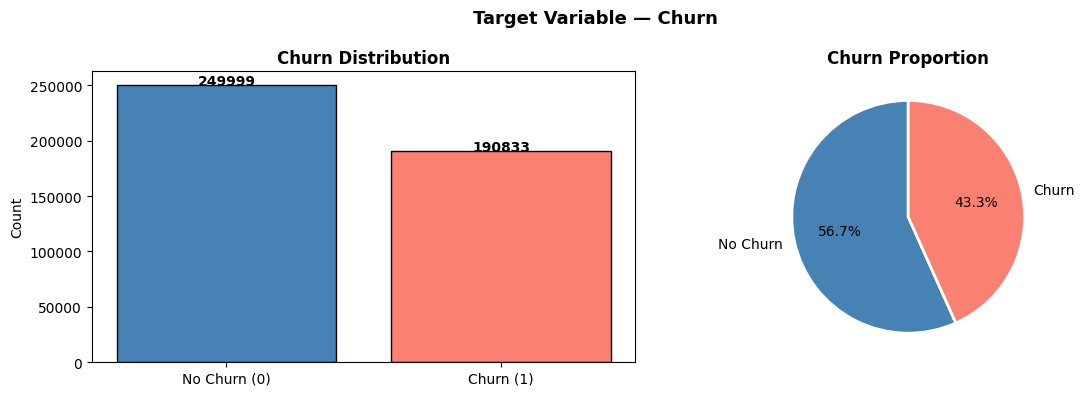

In [34]:
# Churn distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df['churn'].value_counts()
axes[0].bar(['No Churn (0)', 'Churn (1)'], counts.values, color=['steelblue','salmon'], edgecolor='black')
axes[0].set_title('Churn Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v+30, str(v), ha='center', fontweight='bold')
axes[1].pie(counts.values, labels=['No Churn','Churn'], autopct='%1.1f%%', colors=['steelblue','salmon'], startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Churn Proportion', fontweight='bold')
plt.suptitle('Target Variable — Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## IQR Outlier Analysis


In [35]:
numeric_cols = df.select_dtypes(include=np.number).columns.drop('churn').tolist()
print("=" * 68)
print(f"{'Column':<18}{'Q1':>7}{'Q3':>7}{'IQR':>7}{'Lower':>9}{'Upper':>9}{'Outliers':>11}")
print("=" * 68)
iqr_info = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo = Q1 - 1.5 * IQR
    hi = Q3 + 1.5 * IQR
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    iqr_info[col] = dict(Q1=Q1, Q3=Q3, IQR=IQR, lower=lo, upper=hi, n_out=n_out)
    print(f"{col:<18}{Q1:>7.2f}{Q3:>7.2f}{IQR:>7.2f}{lo:>9.2f}{hi:>9.2f}{n_out:>11}")
print("=" * 68)

Column                 Q1     Q3    IQR    Lower    Upper   Outliers
age                 29.00  48.00  19.00     0.50    76.50          0
gender               0.00   1.00   1.00    -1.50     2.50          0
tenure              16.00  46.00  30.00   -29.00    91.00          0
usage_frequency      9.00  23.00  14.00   -12.00    44.00          0
support_calls        1.00   6.00   5.00    -6.50    13.50          0
payment_delay        6.00  19.00  13.00   -13.50    38.50          0
total_spend        480.00 830.00 350.00   -45.00  1355.00          0
last_interaction     7.00  22.00  15.00   -15.50    44.50          0


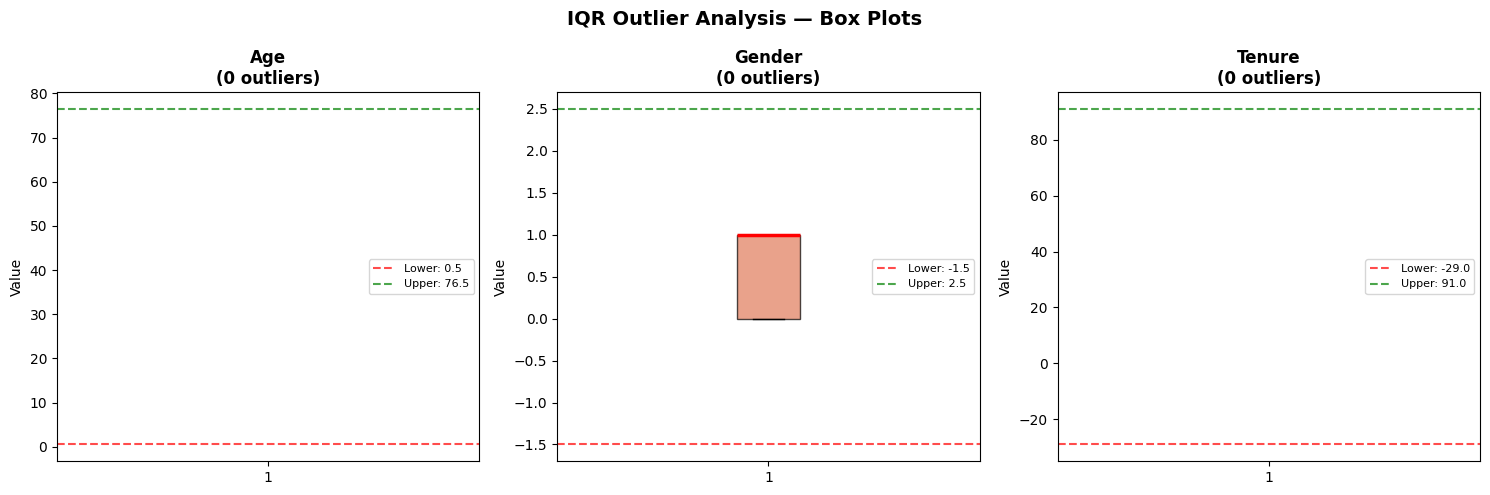

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('IQR Outlier Analysis — Box Plots', fontsize=14, fontweight='bold')
colors = ['#4e91d2', '#e07b5a', '#5cbf7a']
for ax, col, c in zip(axes, numeric_cols, colors):
    info = iqr_info[col]
    ax.boxplot(df[col], patch_artist=True, boxprops=dict(facecolor=c, color='black', alpha=0.7), medianprops=dict(color='red', linewidth=2.5), flierprops=dict(marker='o', color='orange', markeredgecolor='darkorange', markersize=3, alpha=0.5), whiskerprops=dict(color='black'), capprops=dict(color='black'))
    ax.axhline(info['lower'], color='red', linestyle='--', alpha=0.7, label=f"Lower: {info['lower']:.1f}")
    ax.axhline(info['upper'], color='green', linestyle='--', alpha=0.7, label=f"Upper: {info['upper']:.1f}")
    ax.set_title(f"{col.capitalize()}\n({info['n_out']} outliers)", fontweight='bold')
    ax.set_ylabel('Value')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 6. Correlation Analysis


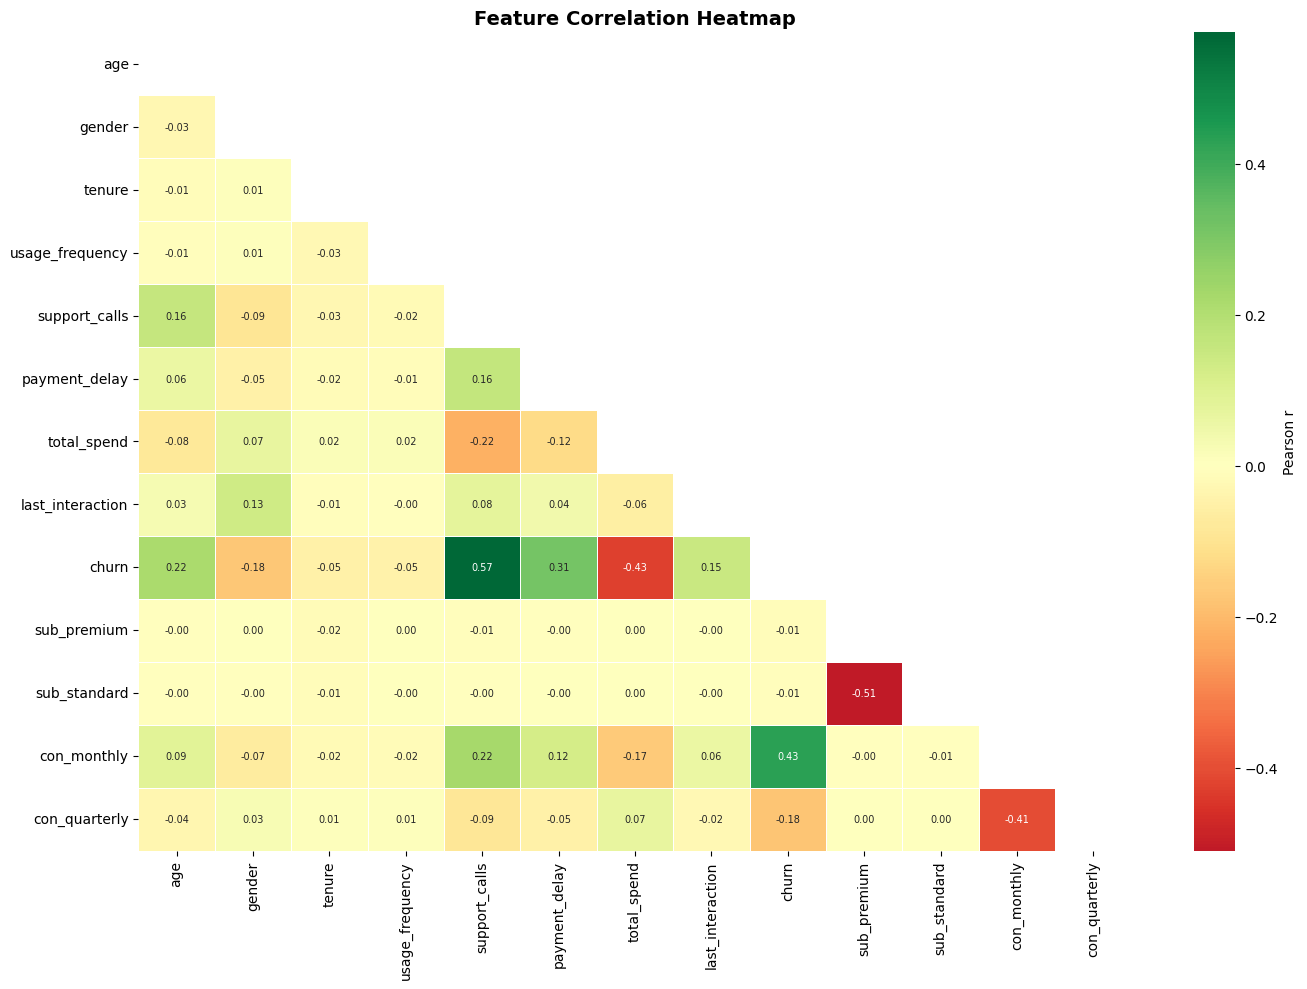

In [37]:
corr = df.corr()
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn', center=0, linewidths=0.5, annot_kws={'size': 7}, cbar_kws={'label': 'Pearson r'})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

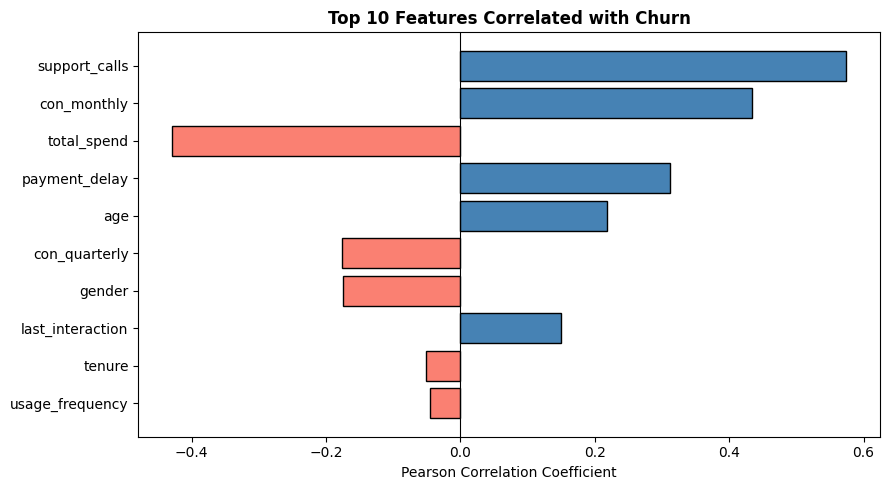


 Top correlations with Churn:
support_calls       0.574267
con_monthly         0.433553
total_spend        -0.429355
payment_delay       0.312129
age                 0.218394
con_quarterly      -0.176244
gender             -0.175395
last_interaction    0.149616
tenure             -0.051919
usage_frequency    -0.046101


In [38]:
churn_corr = corr['churn'].drop('churn').sort_values(key=abs, ascending=False)
top10 = churn_corr.head(10)
plt.figure(figsize=(9, 5))
colors = ['salmon' if v < 0 else 'steelblue' for v in top10.values]
plt.barh(top10.index[::-1], top10.values[::-1], color=colors[::-1], edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 10 Features Correlated with Churn', fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.show()
print("\n Top correlations with Churn:")
print(top10.to_string())

## 7. Train/Test Split


In [39]:

df.dropna(subset=['churn'], inplace=True)

X = df.drop('churn', axis=1)
y = df['churn']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

## 8. Apply Algorithms

In [40]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    print(f"\n{'='*50}")
    print(f" {name}")
    print(f"{'='*50}")
    print(f" Accuracy : {acc*100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_te, y_pred, target_names=['No Churn','Churn']))
    cm = confusion_matrix(y_te, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
    plt.title(f'{name} — Confusion Matrix', fontweight='bold')
    plt.ylabel('Actual'); plt.xlabel('Predicted')
    plt.tight_layout(); plt.show()
    return acc
results = {}

### 9. Decision Tree


 Decision Tree
 Accuracy : 97.74%

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.95      1.00      0.97     38167
       Churn       1.00      0.96      0.98     50000

    accuracy                           0.98     88167
   macro avg       0.98      0.98      0.98     88167
weighted avg       0.98      0.98      0.98     88167



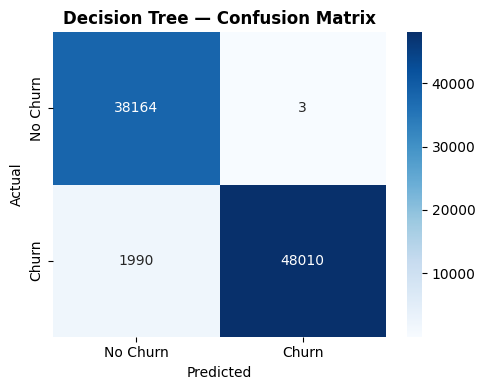

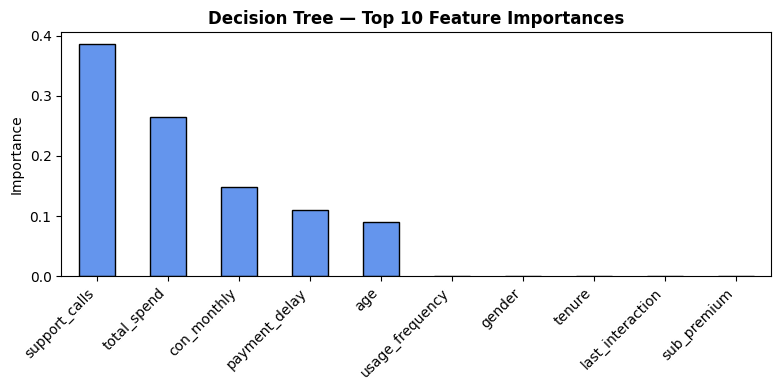

In [41]:
from sklearn.tree import DecisionTreeClassifier, export_text
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
model = DecisionTreeClassifier(
    class_weight='balanced',
    max_depth=5,
    min_samples_leaf=20,
    random_state=42
)
results['Decision Tree'] = evaluate_model(
    'Decision Tree', dt, X_train, y_train, X_test, y_test)


fi = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(8,4))
fi.plot(kind='bar', color='cornflowerblue', edgecolor='black')
plt.title('Decision Tree — Top 10 Feature Importances', fontweight='bold')
plt.ylabel('Importance'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

### 11. Naive Bayes


 Naive Bayes
 Accuracy : 86.29%

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.76      1.00      0.86     38167
       Churn       1.00      0.76      0.86     50000

    accuracy                           0.86     88167
   macro avg       0.88      0.88      0.86     88167
weighted avg       0.90      0.86      0.86     88167



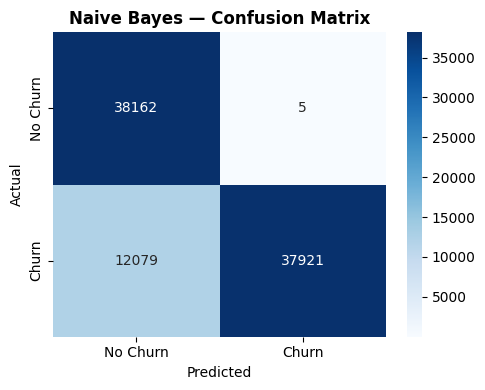

In [42]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
results['Naive Bayes'] = evaluate_model(
    'Naive Bayes', nb, X_train, y_train, X_test, y_test)

### 12. Linear Regression (for classification)




 Linear Regression
 Accuracy : 88.56%

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.82      0.95      0.88     38167
       Churn       0.95      0.84      0.89     50000

    accuracy                           0.89     88167
   macro avg       0.89      0.89      0.89     88167
weighted avg       0.89      0.89      0.89     88167



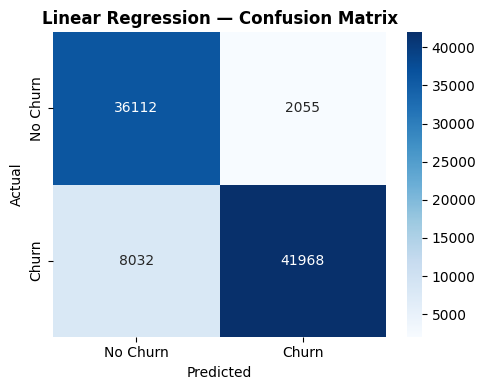

In [43]:
from sklearn.linear_model import LinearRegression



lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr_continuous = lr.predict(X_test)
y_pred_lr_binary = (y_pred_lr_continuous > 0.5).astype(int) # Threshold at 0.5



class LinearRegressionClassifier(LinearRegression):
    def predict(self, X):
        return (super().predict(X) > 0.5).astype(int)

lr_classifier = LinearRegressionClassifier()
results['Linear Regression'] = evaluate_model(
    'Linear Regression', lr_classifier, X_train, y_train, X_test, y_test)

### 13. Logistic Regression


 Logistic Regression
 Accuracy : 89.33%

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.86      0.90      0.88     38167
       Churn       0.92      0.89      0.90     50000

    accuracy                           0.89     88167
   macro avg       0.89      0.89      0.89     88167
weighted avg       0.89      0.89      0.89     88167



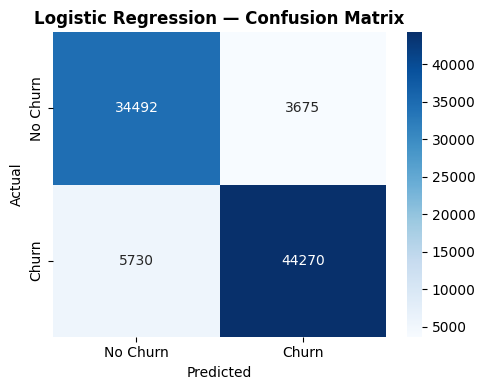

In [44]:
from sklearn.linear_model import LogisticRegression


log_reg = LogisticRegression(random_state=42, solver='liblinear', max_iter=200)
results['Logistic Regression'] = evaluate_model(
    'Logistic Regression', log_reg, X_train, y_train, X_test, y_test)

## 14. Model Comparison

/tmp/ipykernel_7546/2564799970.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=results_df, palette='viridis')


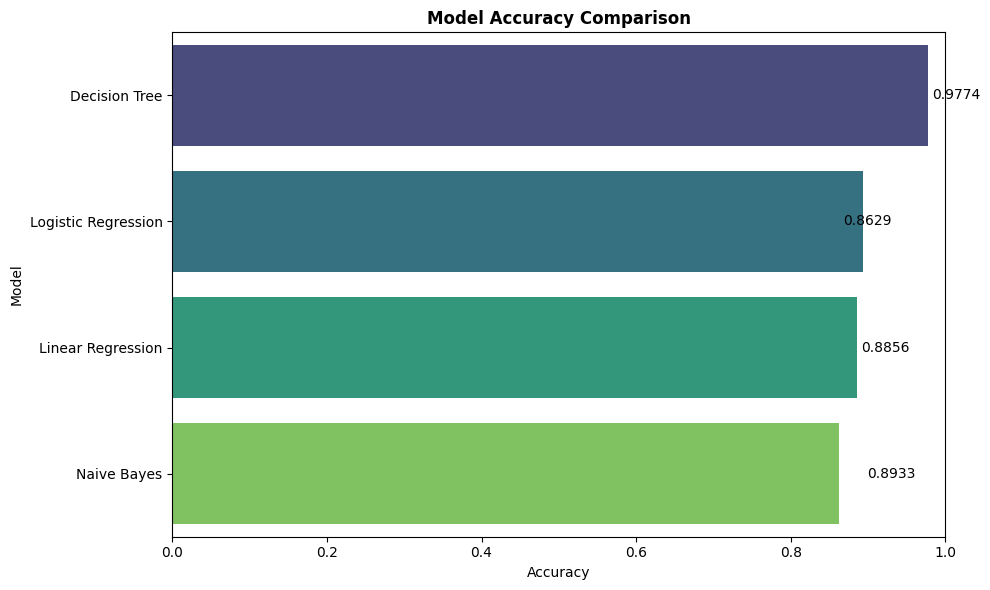


Accuracy Comparison:


,Model,Accuracy
0,Decision Tree,0.977395
3,Logistic Regression,0.893327
2,Linear Regression,0.885592
1,Naive Bayes,0.862942


In [45]:
results_df = pd.DataFrame(results.items(), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=results_df, palette='viridis')
plt.title('Model Accuracy Comparison', fontweight='bold')
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.xlim(0, 1)

for index, row in results_df.iterrows():
    plt.text(row.Accuracy + 0.005, index, f'{row.Accuracy:.4f}', color='black', ha="left", va="center")

plt.tight_layout()
plt.show()

print("\nAccuracy Comparison:")
display(results_df)

## 10. Pickle file

In [46]:
import pickle


model_filename = 'decision_tree_model.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(dt, file)

print(f" Decision Tree model saved to '{model_filename}'")

 Decision Tree model saved to 'decision_tree_model.pkl'
